In [35]:
# Vẽ biểu đồ
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chia dữ liệu, cross-validation, tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score

# Tiền xử lý dữ liệu
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Các mô hình hồi quy
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Đánh giá mô hình
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
salary = pd.read_csv("data/job_salary_prediction_dataset.csv")
salary

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


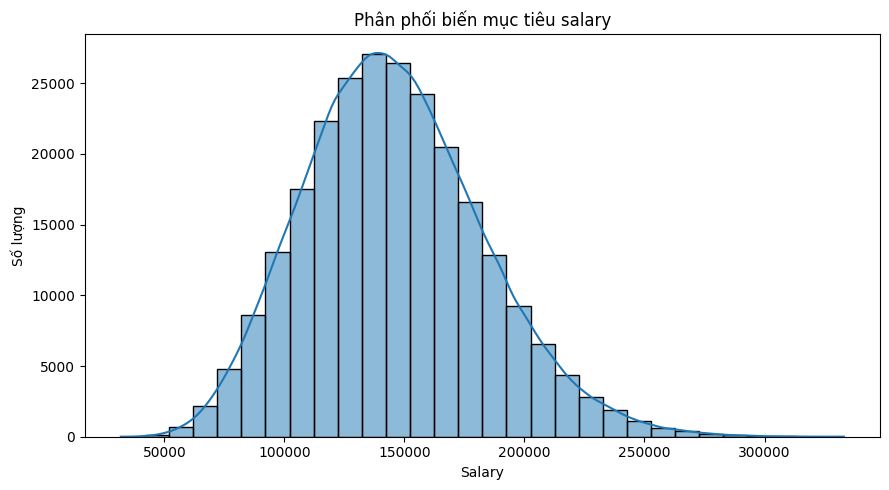

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("Images", exist_ok=True)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=salary,
    x="salary",
    bins=30,
    kde=True
)

plt.title("Phân phối biến mục tiêu salary")
plt.xlabel("Salary")
plt.ylabel("Số lượng")
plt.tight_layout()

plt.savefig("Images/salary_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [38]:
salary.shape

(250000, 10)

In [39]:
salary.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [40]:
# Kiểm tra kích thước ban đầu
print("Kích thước dữ liệu ban đầu:", salary.shape)

# Kiểm tra giá trị NULL ở từng cột
null_count = salary.isnull().sum()
null_ratio = salary.isnull().mean() * 100

null_summary = pd.DataFrame({
    "Null_count": null_count,
    "Null_ratio_%": null_ratio
})

print("Thống kê NULL:")
display(null_summary)

# Kiểm tra tổng số giá trị NULL
print("Tổng số giá trị NULL:", salary.isnull().sum().sum())

# Kiểm tra số dòng bị trùng lặp
duplicate_count = salary.duplicated().sum()
print("Số dòng trùng lặp:", duplicate_count)

Kích thước dữ liệu ban đầu: (250000, 10)
Thống kê NULL:


,Null_count,Null_ratio_%
job_title,0,0.0
experience_years,0,0.0
education_level,0,0.0
skills_count,0,0.0
industry,0,0.0
company_size,0,0.0
location,0,0.0
remote_work,0,0.0
certifications,0,0.0
salary,0,0.0


Tổng số giá trị NULL: 0
Số dòng trùng lặp: 0


In [41]:
salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [42]:
salary.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [43]:
salary.describe(include='all')

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
count,250000,250000.000000,250000,250000.000000,250000,250000,250000,250000,250000.000000,250000.000000
unique,12,NaN,5,NaN,10,5,10,3,NaN,NaN
top,Backend Developer,NaN,Master,NaN,Finance,Large,Australia,No,NaN,NaN
freq,21125,NaN,50352,NaN,25393,50254,25258,83621,NaN,NaN
mean,NaN,10.005408,NaN,9.997812,NaN,NaN,NaN,NaN,2.491928,145718.080524
std,NaN,6.060602,NaN,5.479288,NaN,NaN,NaN,NaN,1.706475,37407.952729
min,NaN,0.000000,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,31867.000000
25%,NaN,5.000000,NaN,5.000000,NaN,NaN,NaN,NaN,1.000000,119358.000000
50%,NaN,10.000000,NaN,10.000000,NaN,NaN,NaN,NaN,2.000000,143453.000000
75%,NaN,15.000000,NaN,15.000000,NaN,NaN,NaN,NaN,4.000000,169492.000000


In [44]:
salary.nunique().sort_values(ascending=False)

salary              118956
experience_years        21
skills_count            19
job_title               12
industry                10
location                10
certifications           6
education_level          5
company_size             5
remote_work              3
dtype: int64

In [45]:
salary["job_title"].value_counts()

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

In [46]:
salary["location"].value_counts()

location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64

In [47]:
salary["certifications"].value_counts()

certifications
0    42015
3    41974
2    41744
1    41574
4    41467
5    41226
Name: count, dtype: int64

In [48]:
salary["company_size"].value_counts()

company_size
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609
Name: count, dtype: int64

In [49]:
salary["remote_work"].value_counts()

remote_work
No        83621
Hybrid    83476
Yes       82903
Name: count, dtype: int64

In [50]:
X = salary.drop("salary", axis=1)
y = salary["salary"]

In [51]:
salary_bins = pd.qcut(y, q=10, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=salary_bins
)

In [52]:
# Lấy lại salary_bins tương ứng với train và test
salary_bins_train = salary_bins.loc[y_train.index]
salary_bins_test = salary_bins.loc[y_test.index]

# So sánh tỉ lệ
compare_bins = pd.DataFrame({
    "Train_ratio": salary_bins_train.value_counts(normalize=True).sort_index(),
    "Test_ratio": salary_bins_test.value_counts(normalize=True).sort_index()
})

# Thêm cột chênh lệch
compare_bins["Difference"] = abs(compare_bins["Train_ratio"] - compare_bins["Test_ratio"])

compare_bins

,Train_ratio,Test_ratio,Difference
salary,,,
0,0.100000,0.1,0.000000
1,0.100005,0.1,0.000005
2,0.099995,0.1,0.000005
3,0.100005,0.1,0.000005
4,0.100010,0.1,0.000010
5,0.099990,0.1,0.000010
6,0.100005,0.1,0.000005
7,0.099995,0.1,0.000005
8,0.100000,0.1,0.000000


In [53]:
import pandas as pd
import numpy as np

train_df = X_train.copy()
test_df = X_test.copy()

train_df["salary"] = y_train
test_df["salary"] = y_test

In [54]:
categorical_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Cột phân loại:", categorical_cols)
print("Cột số:", numeric_cols)

Cột phân loại: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
Cột số: ['experience_years', 'skills_count', 'certifications', 'salary']


In [55]:
def compare_categorical_distribution(col):
    train_ratio = train_df[col].value_counts(normalize=True).sort_index()
    test_ratio = test_df[col].value_counts(normalize=True).sort_index()

    compare = pd.DataFrame({
        "Train_ratio": train_ratio,
        "Test_ratio": test_ratio
    }).fillna(0)

    compare["Difference"] = abs(compare["Train_ratio"] - compare["Test_ratio"])

    return compare.sort_values("Difference", ascending=False)

In [56]:
compare_categorical_distribution("job_title")

,Train_ratio,Test_ratio,Difference
job_title,,,
AI Engineer,0.084255,0.08188,0.002375
Cloud Engineer,0.082370,0.08424,0.001870
Backend Developer,0.084155,0.08588,0.001725
Frontend Developer,0.082215,0.08380,0.001585
DevOps Engineer,0.083840,0.08242,0.001420
Business Analyst,0.082850,0.08156,0.001290
Data Scientist,0.083345,0.08442,0.001075
Software Engineer,0.083640,0.08296,0.000680
Data Analyst,0.082995,0.08246,0.000535


In [57]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.model_selection import cross_validate

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [58]:
numeric_features = [
    "experience_years",
    "skills_count",
    "certifications"
]

ordinal_features = [
    "education_level",
    "company_size"
]

nominal_features = [
    "job_title",
    "industry",
    "location",
    "remote_work"
]

education_order = [
    "High School",
    "Diploma",
    "Bachelor",
    "Master",
    "PhD"
]

company_size_order = [
    "Startup",
    "Small",
    "Medium",
    "Large",
    "Enterprise"
]


numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(categories=[
        education_order,
        company_size_order
    ]))
])

# Tương thích nhiều phiên bản sklearn
try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

nominal_transformer = Pipeline(steps=[
    ("onehot", onehot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("nom", nominal_transformer, nominal_features)
    ],
    sparse_threshold=0
)

In [59]:
X_train_cv = X_train
y_train_cv = y_train

print("Kích thước tập dùng để cross-validation:", X_train_cv.shape)

Kích thước tập dùng để cross-validation: (200000, 9)


In [60]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

import pandas as pd
import numpy as np
import time

In [61]:
X_train_cv = X_train
y_train_cv = y_train

print("Kích thước tập dùng để cross-validation:", X_train_cv.shape)

Kích thước tập dùng để cross-validation: (200000, 9)


In [62]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=15,
        min_samples_leaf=20
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=50,
        max_depth=15,
        min_samples_leaf=20,
        n_jobs=-1
    )

}

In [63]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, regressor in models.items():
    print("=" * 50)
    print("Đang chạy:", name)

    start_time = time.time()

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

    scores = cross_validate(
        model,
        X_train_cv,
        y_train_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    run_time = time.time() - start_time

    cv_results.append({
        "Model": name,
        "CV_MAE_mean": -scores["test_MAE"].mean(),
        
        "CV_RMSE_mean": -scores["test_RMSE"].mean(),
        
        "CV_R2_mean": scores["test_R2"].mean(),
        
        "Time_seconds": run_time
    })

    print("Xong:", name)
    print("Thời gian:", round(run_time, 2), "giây")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(by="CV_R2_mean", ascending=False)

cv_results_df

Đang chạy: Linear Regression
Xong: Linear Regression
Thời gian: 6.41 giây
Đang chạy: Ridge Regression
Xong: Ridge Regression
Thời gian: 4.16 giây
Đang chạy: Decision Tree


MemoryError: Unable to allocate 3.66 MiB for an array with shape (3, 160000) and data type int64

In [ ]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

import pandas as pd
import numpy as np
import time

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42,
        max_iter=100,
        learning_rate=0.1
    )
}

In [ ]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, regressor in models.items():
    print("=" * 50)
    print("Đang chạy:", name)
    
    start_time = time.time()
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])
    
    scores = cross_validate(
        model,
        X_train_cv,
        y_train_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    run_time = time.time() - start_time
    
    cv_results.append({
        "Model": name,
        "CV_MAE_mean": -scores["test_MAE"].mean(),
        "CV_MAE_std": scores["test_MAE"].std(),
        "CV_RMSE_mean": -scores["test_RMSE"].mean(),
        "CV_RMSE_std": scores["test_RMSE"].std(),
        "CV_R2_mean": scores["test_R2"].mean(),
        "CV_R2_std": scores["test_R2"].std(),
        "Time_seconds": run_time
    })
    
    print("Xong:", name)
    print("Thời gian:", round(run_time, 2), "giây")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(by="CV_R2_mean", ascending=False)

cv_results_df

Đang chạy: Linear Regression


Xong: Linear Regression
Thời gian: 1.66 giây
Đang chạy: Ridge Regression
Xong: Ridge Regression
Thời gian: 0.96 giây
Đang chạy: Hist Gradient Boosting
Xong: Hist Gradient Boosting
Thời gian: 7.74 giây


,Model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,Time_seconds
2,Hist Gradient Boosting,4366.990026,9.743884,5486.201418,17.086598,0.978486,0.000287,7.736521
0,Linear Regression,6072.820127,23.272149,7898.869707,36.732675,0.955406,0.000357,1.656180
1,Ridge Regression,6072.799859,23.274974,7898.869912,36.732735,0.955406,0.000357,0.963121


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import time

In [ ]:
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", HistGradientBoostingRegressor(
        random_state=42,
        early_stopping=True
    ))
])

In [ ]:
param_dist = {
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "regressor__max_iter": [100, 150, 200, 300, 400],
    "regressor__max_leaf_nodes": [15, 31, 63, 127],
    "regressor__max_depth": [None, 5, 10, 15, 20],
    "regressor__min_samples_leaf": [10, 20, 30, 50, 100],
    "regressor__l2_regularization": [0.0, 0.01, 0.1, 1.0, 10.0],
    "regressor__max_bins": [64, 128, 255]
}

In [ ]:
search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

start_time = time.time()

search.fit(X_train, y_train)

end_time = time.time()

print("Thời gian tuning:", round(end_time - start_time, 2), "giây")
print("Best CV R2:", search.best_score_)
print("Best parameters:")
print(search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Thời gian tuning: 457.63 giây
Best CV R2: 0.9809721773462204
Best parameters:
{'regressor__min_samples_leaf': 100, 'regressor__max_leaf_nodes': 63, 'regressor__max_iter': 400, 'regressor__max_depth': 5, 'regressor__max_bins': 255, 'regressor__learning_rate': 0.1, 'regressor__l2_regularization': 10.0}


In [ ]:
tuning_results = pd.DataFrame(search.cv_results_)

tuning_results = tuning_results[
    [
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
        "param_regressor__learning_rate",
        "param_regressor__max_iter",
        "param_regressor__max_leaf_nodes",
        "param_regressor__max_depth",
        "param_regressor__min_samples_leaf",
        "param_regressor__l2_regularization",
        "param_regressor__max_bins"
    ]
]

tuning_results = tuning_results.sort_values(by="rank_test_score")

tuning_results.head(10)

,mean_test_score,std_test_score,rank_test_score,param_regressor__learning_rate,param_regressor__max_iter,param_regressor__max_leaf_nodes,param_regressor__max_depth,param_regressor__min_samples_leaf,param_regressor__l2_regularization,param_regressor__max_bins
5,0.980972,0.000159,1,0.10,400,63,5,100,10.00,255
14,0.980935,0.000191,2,0.10,400,63,5,50,1.00,64
24,0.980643,0.000134,3,0.03,400,127,15,100,0.00,64
27,0.980614,0.000136,4,0.05,400,63,15,100,0.01,128
29,0.980567,0.000151,5,0.05,400,63,15,10,0.00,128
23,0.980555,0.000100,6,0.07,300,63,10,50,10.00,255
13,0.980436,0.000076,7,0.07,300,31,10,100,0.10,64
28,0.980365,0.000123,8,0.05,200,127,None,20,0.00,128
2,0.980296,0.000167,9,0.05,400,15,10,100,0.01,128
16,0.980233,0.000089,10,0.07,400,15,20,10,1.00,64


In [ ]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)

Test MAE: 4126.29729185493
Test RMSE: 5169.0838536735755
Test R2: 0.980911560976723


In [ ]:
final_result = pd.DataFrame({
    "Model": ["Tuned Hist Gradient Boosting"],
    "CV_R2": [search.best_score_],
    "Test_MAE": [test_mae],
    "Test_RMSE": [test_rmse],
    "Test_R2": [test_r2]
})

final_result

,Model,CV_R2,Test_MAE,Test_RMSE,Test_R2
0,Tuned Hist Gradient Boosting,0.980972,4126.297292,5169.083854,0.980912


In [ ]:
import joblib
joblib.dump(best_model, "data/best_salary_prediction_model.pkl")


['best_salary_prediction_model.pkl']

In [ ]:
loaded_model = joblib.load("data/best_salary_prediction_model.pkl")
loaded_pred = loaded_model.predict(X_test)

print("R2 sau khi load lại:", r2_score(y_test, loaded_pred))

R2 sau khi load lại: 0.980911560976723


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import time

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
param_dist_rf = {
    "regressor__n_estimators": [50, 100, 150],
    "regressor__max_depth": [10, 15, 20, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 5, 10, 20],
    "regressor__max_features": ["sqrt", "log2", 0.5, 0.8],
    "regressor__bootstrap": [True]
}

In [ ]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=15,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

start_time = time.time()

rf_search.fit(X_train, y_train)

end_time = time.time()

print("Thời gian tuning RF:", round(end_time - start_time, 2), "giây")
print("Best CV R2:", rf_search.best_score_)
print("Best parameters:")
print(rf_search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Thời gian tuning RF: 756.24 giây
Best CV R2: 0.9668337822086226
Best parameters:
{'regressor__n_estimators': 100, 'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.8, 'regressor__max_depth': 20, 'regressor__bootstrap': True}


In [ ]:
best_rf_model = rf_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)

rf_test_mae = mean_absolute_error(y_test, y_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_test_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Test MAE:", rf_test_mae)
print("Random Forest Test RMSE:", rf_test_rmse)
print("Random Forest Test R2:", rf_test_r2)

Random Forest Test MAE: 5361.785989884181
Random Forest Test RMSE: 6737.2683871188165
Random Forest Test R2: 0.9675726875033582


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import time

In [ ]:
rf_pipeline_refine = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        min_samples_split=5,
        min_samples_leaf=1,
        bootstrap=True
    ))
])

In [ ]:
param_grid_rf_refine = {
    "regressor__n_estimators": [100, 120],
    "regressor__max_depth": [18, 20, 22],
    "regressor__max_features": [0.75, 0.8, 0.85]
}

In [ ]:
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline_refine,
    param_grid=param_grid_rf_refine,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2
)

start_time = time.time()

rf_grid_search.fit(X_train, y_train)

end_time = time.time()

print("Thời gian GridSearch RF:", round(end_time - start_time, 2), "giây")
print("Best CV R2:", rf_grid_search.best_score_)
print("Best parameters:")
print(rf_grid_search.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Thời gian GridSearch RF: 2038.71 giây
Best CV R2: 0.9696103625382234
Best parameters:
{'regressor__max_depth': 22, 'regressor__max_features': 0.75, 'regressor__n_estimators': 120}


In [ ]:
best_rf_grid_model = rf_grid_search.best_estimator_

y_pred_rf_grid = best_rf_grid_model.predict(X_test)

rf_grid_test_mae = mean_absolute_error(y_test, y_pred_rf_grid)
rf_grid_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_grid))
rf_grid_test_r2 = r2_score(y_test, y_pred_rf_grid)

print("Random Forest GridSearch Test MAE:", rf_grid_test_mae)
print("Random Forest GridSearch Test RMSE:", rf_grid_test_rmse)
print("Random Forest GridSearch Test R2:", rf_grid_test_r2)

Random Forest GridSearch Test MAE: 5108.274434342469
Random Forest GridSearch Test RMSE: 6414.7942012674075
Random Forest GridSearch Test R2: 0.9706026139233179


In [ ]:
joblib.dump(best_rf_grid_model, "data/best_salary_prediction_model.pkl")

['best_salary_prediction_modelv2.pkl']

# PHẦN 2: BÀI TOÁN TỐI ƯU HÓA PHÂN BỔ NGUỒN LỰC (ILP)

Trong phần này, chúng ta xây dựng mô hình **Quy hoạch tuyến tính nguyên (Integer Linear Programming - ILP)** để tối ưu hóa phân bổ nguồn lực tuyển dụng. Mục tiêu là tối đa hóa chất lượng đội ngũ tuyển dụng trong phạm vi ngân sách giới hạn và thỏa mãn các ràng buộc về cơ cấu nhân sự (chức danh, kinh nghiệm, học vấn, chứng chỉ, kỹ năng, hình thức làm việc).


In [67]:
# 1. Tính toán điểm chất lượng tổng hợp (Composite Quality Index) và chi phí tuyển dụng dự báo cho từng ứng viên
import numpy as np
import pandas as pd
import joblib
import os

# Load dữ liệu
csv_path = 'data/job_salary_prediction_dataset.csv'
salary_df = pd.read_csv(csv_path)

# Load model ML đã được huấn luyện
model_path = 'data/best_salary_prediction_model.pkl'
if os.path.exists(model_path):
    best_model = joblib.load(model_path)
    print('Đã tải mô hình ML dự báo lương thành công.')
else:
    print('Mô hình ML dự báo lương không tồn tại trong thư mục! Vui lòng kiểm tra lại.')

# Tính toán các điểm thành phần của chỉ số chất lượng
# 1. Điểm kỹ năng s: scale kỹ năng từ [1, 19] thành [0, 10]
s = 10 * (salary_df['skills_count'] - 1) / 18

# 2. Điểm chứng chỉ t: scale chứng chỉ từ [0, 5] thành [0, 10]
t = 10 * salary_df['certifications'] / 5

# 3. Điểm kinh nghiệm y: phi tuyến tính (logarithmic scale) từ [0, 20] năm thành [0, 10]
y = 10 * np.log1p(salary_df['experience_years']) / np.log(21)

# 4. Điểm trình độ học vấn d
edu_mapping = {'High School': 2, 'Diploma': 4, 'Bachelor': 6, 'Master': 8, 'PhD': 10}
d = salary_df['education_level'].map(edu_mapping)

# 5. Điểm quy mô công ty đã từng làm việc f
company_mapping = {'Startup': 4, 'Small': 5, 'Medium': 6, 'Large': 8, 'Enterprise': 10}
f = salary_df['company_size'].map(company_mapping)

# Điểm chất lượng tổng hợp Composite Quality Index (q)
salary_df['quality_score'] = 0.25 * s + 0.08 * t + 0.47 * y + 0.11 * d + 0.09 * f

# Dự đoán lương bằng mô hình ML
X_features = salary_df.drop('salary', axis=1)
salary_df['predicted_salary'] = best_model.predict(X_features)

# Tính chi phí tuyển dụng ước tính p = (1 + alpha) * predicted_salary, với alpha = 0.3
alpha = 0.3
salary_df['recruitment_cost'] = (1 + alpha) * salary_df['predicted_salary']

print('Đã tính toán xong chỉ số chất lượng và chi phí tuyển dụng dự báo cho toàn bộ ứng viên.')
print(salary_df[['job_title', 'recruitment_cost', 'quality_score']].head())


Đã tải mô hình ML dự báo lương thành công.
Đã tính toán xong chỉ số chất lượng và chi phí tuyển dụng dự báo cho toàn bộ ứng viên.
            job_title  recruitment_cost  quality_score
0         AI Engineer     136194.348608       5.360654
1        Data Analyst     117881.670120       6.098262
2  Frontend Developer     199199.233609       6.762162
3    Business Analyst     239043.307909       7.931347
4     Product Manager     220554.156777       6.493534


In [68]:
# 2. Xây dựng hàm giải bài toán tối ưu phân bổ nguồn lực tuyển dụng (ILP) bằng PuLP
import pulp

def solve_recruitment_ilp(
    df,
    budget,
    headcount,
    allowed_titles=None,
    min_exp=0,
    min_skills=1,
    min_certs=0,
    min_avg_quality=0.0,
    job_title_bounds=None,      # dict: {job_title: (min, max)}
    title_balance_limit=None,   # tỉ lệ trần tối đa cho mỗi chức danh trong headcount
    exp_requirements=None,      # dict: {'senior_years', 'min_senior_ratio', 'fresher_years', 'max_fresher_ratio'}
    edu_requirements=None,      # dict: {'levels', 'min_ratio'}
    remote_requirements=None    # dict: {'min_hybrid_ratio', 'max_remote_ratio'}
):
    # 2.1. Lọc ứng viên sơ bộ dựa trên các tiêu chí tuyển dụng cứng
    filtered_df = df.copy()
    if allowed_titles:
        filtered_df = filtered_df[filtered_df['job_title'].isin(allowed_titles)]
    filtered_df = filtered_df[
        (filtered_df['experience_years'] >= min_exp) &
        (filtered_df['skills_count'] >= min_skills) &
        (filtered_df['certifications'] >= min_certs)
    ]
    
    # Reset index để khớp index của biến quyết định trong PuLP
    filtered_df = filtered_df.reset_index(drop=True)
    n_candidates = len(filtered_df)
    print(f'Số lượng ứng viên thỏa mãn tiêu chí tuyển dụng cứng: {n_candidates}')
    
    if n_candidates == 0:
        print('Không có ứng viên nào đáp ứng yêu cầu!')
        return None
        
    # 2.2. Khởi tạo bài toán tối ưu nguyên (ILP) tìm phương án tối đa chất lượng
    prob = pulp.LpProblem('Recruitment_Resource_Allocation', pulp.LpMaximize)
    
    # Biến quyết định: x_h = 1 nếu tuyển ứng viên h, ngược lại 0
    x = [pulp.LpVariable(f'x_{h}', cat='Binary') for h in range(n_candidates)]
    
    # 2.3. Hàm mục tiêu: Tối đa hóa tổng điểm chất lượng của đội ngũ được tuyển dụng
    prob += pulp.lpSum(filtered_df.loc[h, 'quality_score'] * x[h] for h in range(n_candidates)), 'Total_Quality_Score'
    
    # 2.4. Ràng buộc ngân sách và tổng headcount tuyển dụng
    # Tổng chi phí tuyển dụng <= Ngân sách
    prob += pulp.lpSum(filtered_df.loc[h, 'recruitment_cost'] * x[h] for h in range(n_candidates)) <= budget, 'Recruitment_Budget'
    
    # Tổng số người được tuyển = headcount
    prob += pulp.lpSum(x[h] for h in range(n_candidates)) == headcount, 'Headcount_Limit'
    
    # 2.5. Ràng buộc về số lượng theo chức danh tuyển dụng cụ thể
    if job_title_bounds:
        for title, (l_bound, u_bound) in job_title_bounds.items():
            title_indices = filtered_df[filtered_df['job_title'] == title].index
            if len(title_indices) > 0:
                if l_bound is not None:
                    prob += pulp.lpSum(x[h] for h in title_indices) >= l_bound, f'Min_Limit_{title.replace(" ", "_")}'
                if u_bound is not None:
                    prob += pulp.lpSum(x[h] for h in title_indices) <= u_bound, f'Max_Limit_{title.replace(" ", "_")}'
                    
    # Ràng buộc cân bằng chức danh (Tránh việc chỉ tuyển duy nhất 1 chức danh hot)
    if title_balance_limit is not None:
        for title in filtered_df['job_title'].unique():
            title_indices = filtered_df[filtered_df['job_title'] == title].index
            prob += pulp.lpSum(x[h] for h in title_indices) <= title_balance_limit * headcount, f'Title_Balance_{title.replace(" ", "_")}'
            
    # 2.6. Ràng buộc chất lượng trung bình tối thiểu
    if min_avg_quality > 0:
        prob += pulp.lpSum(filtered_df.loc[h, 'quality_score'] * x[h] for h in range(n_candidates)) >= min_avg_quality * headcount, 'Min_Average_Quality'
        
    # 2.7. Ràng buộc về cơ cấu kinh nghiệm
    if exp_requirements:
        # Senior / Expert ratio
        if 'senior_years' in exp_requirements and 'min_senior_ratio' in exp_requirements:
            sen_yrs = exp_requirements['senior_years']
            min_ratio = exp_requirements['min_senior_ratio']
            senior_indices = filtered_df[filtered_df['experience_years'] >= sen_yrs].index
            prob += pulp.lpSum(x[h] for h in senior_indices) >= min_ratio * headcount, 'Min_Senior_Expert_Ratio'
        # Fresher / Junior limit ratio
        if 'fresher_years' in exp_requirements and 'max_fresher_ratio' in exp_requirements:
            fresh_yrs = exp_requirements['fresher_years']
            max_ratio = exp_requirements['max_fresher_ratio']
            fresher_indices = filtered_df[filtered_df['experience_years'] <= fresh_yrs].index
            prob += pulp.lpSum(x[h] for h in fresher_indices) <= max_ratio * headcount, 'Max_Fresher_Junior_Ratio'
            
    # 2.8. Ràng buộc về cơ cấu trình độ học vấn
    if edu_requirements:
        edu_lvls = edu_requirements.get('levels', [])
        min_ratio = edu_requirements.get('min_ratio', 0.0)
        edu_indices = filtered_df[filtered_df['education_level'].isin(edu_lvls)].index
        prob += pulp.lpSum(x[h] for h in edu_indices) >= min_ratio * headcount, 'Min_Education_Level_Ratio'
        
    # 2.9. Ràng buộc về cơ cấu hình thức làm việc
    if remote_requirements:
        # Yêu cầu tối thiểu về nhân sự làm Hybrid
        if 'min_hybrid_ratio' in remote_requirements:
            hybrid_indices = filtered_df[filtered_df['remote_work'] == 'Hybrid'].index
            prob += pulp.lpSum(x[h] for h in hybrid_indices) >= remote_requirements['min_hybrid_ratio'] * headcount, 'Min_Hybrid_Ratio'
        # Giới hạn tối đa nhân sự làm Remote hoàn toàn
        if 'max_remote_ratio' in remote_requirements:
            remote_indices = filtered_df[filtered_df['remote_work'] == 'Yes'].index
            prob += pulp.lpSum(x[h] for h in remote_indices) <= remote_requirements['max_remote_ratio'] * headcount, 'Max_Remote_Ratio'
            
    # 2.10. Chạy thuật toán giải
    solver = pulp.PULP_CBC_CMD(msg=False)
    status = prob.solve(solver)
    
    if pulp.LpStatus[status] == 'Optimal':
        selected_indices = [h for h in range(n_candidates) if pulp.value(x[h]) > 0.5]
        selected_candidates = filtered_df.iloc[selected_indices].copy()
        print(f'Tìm thấy phương án tối ưu! (Trạng thái: Optimal)')
        return selected_candidates
    else:
        print(f'Không tìm được phương án tối ưu. Trạng thái solver: {pulp.LpStatus[status]}')
        return None


In [71]:
# 3. Kịch bản tuyển dụng thực tế và chạy bộ tối ưu hóa
# Cấu hình kịch bản tuyển dụng cho dự án mới:
# - Ngân sách: 1,500,000 USD
# - Số lượng cần tuyển: N = 10 nhân sự
# - Các chức danh cần tuyển: AI Engineer, Data Scientist, Data Analyst
# - Tiêu chuẩn cứng: Kinh nghiệm >= 1 năm, Kỹ năng >= 8
# - Cơ cấu kinh nghiệm: Ít nhất 30% có từ 5 năm kinh nghiệm trở lên (Senior)
# - Cơ cấu học vấn: Ít nhất 40% có trình độ Master hoặc PhD
# - Cơ cấu làm việc: Ít nhất 50% làm việc Hybrid, tối đa 20% làm Remote hoàn toàn
# - Ràng buộc phân bổ: Tối đa 40% headcount tuyển dụng cho mỗi chức danh để đảm bảo đa dạng

budget_val = 1500000
headcount_val = 10
allowed_titles = ['AI Engineer', 'Data Scientist', 'Data Analyst', 'Machine Learning Engineer', 'Business Intelligence Analyst']

job_title_bounds = {
    'AI Engineer': (1, 4),      # tuyển ít nhất 1, tối đa 4 AI Engineer
    'Data Scientist': (1, 4),   # tuyển ít nhất 1, tối đa 4 Data Scientist
    'Data Analyst': (1, 4),     # tuyển ít nhất 1, tối đa 4 Data Analyst
    'Machine Learning Engineer': (1, 4),  # tuyển ít nhất 1, tối đa 4 Machine Learning Engineer
    'Business Intelligence Analyst': (1, 4)  # tuyển ít nhất 1, tối đa 4 Business Intelligence Analyst
}

exp_requirements = {
    'senior_years': 5,
    'min_senior_ratio': 0.3,
    'fresher_years': 2,
    'max_fresher_ratio': 0.3
}

edu_requirements = {
    'levels': ['Master', 'PhD'],
    'min_ratio': 0.4
}

remote_requirements = {
    'min_hybrid_ratio': 0.5,
    'max_remote_ratio': 0.2
}

selected_recruits = solve_recruitment_ilp(
    df=salary_df,
    budget=budget_val,
    headcount=headcount_val,
    allowed_titles=allowed_titles,
    min_exp=1,
    min_skills=8,
    min_certs=0,
    job_title_bounds=job_title_bounds,
    title_balance_limit=0.4,
    exp_requirements=exp_requirements,
    edu_requirements=edu_requirements,
    remote_requirements=remote_requirements
)

if selected_recruits is not None:
    print('\n================ KẾT QUẢ PHÂN BỔ TỐI ƯU CƠ CẤU TUYỂN DỤNG ================')
    print(f'Tổng số lượng tuyển dụng: {len(selected_recruits)} người')
    print(f'Tổng chi phí dự tính: ${selected_recruits["recruitment_cost"].sum():,.2f} / Ngân sách cho phép: ${budget_val:,.2f}')
    print(f'Điểm chất lượng trung bình của đội ngũ mới: {selected_recruits["quality_score"].mean():.2f}/10.0')
    
    print('\nDanh sách nhân sự được tuyển chọn:')
    display(selected_recruits[['job_title', 'experience_years', 'education_level', 'remote_work', 'company_size', 'recruitment_cost', 'quality_score']])
    
    print('\nThống kê cơ cấu chức danh tuyển dụng:')
    display(selected_recruits['job_title'].value_counts())
    
    print('\nThống kê cơ cấu hình thức làm việc:')
    display(selected_recruits['remote_work'].value_counts())
else:
    print('Bài toán không có phương án khả thi! Vui lòng nới lỏng các ràng buộc.')


Số lượng ứng viên thỏa mãn tiêu chí tuyển dụng cứng: 50134
Tìm thấy phương án tối ưu! (Trạng thái: Optimal)

================ KẾT QUẢ PHÂN BỔ TỐI ƯU CƠ CẤU TUYỂN DỤNG ================
Tổng số lượng tuyển dụng: 10 người
Tổng chi phí dự tính: $1,496,962.64 / Ngân sách cho phép: $1,500,000.00
Điểm chất lượng trung bình của đội ngũ mới: 9.14/10.0

Danh sách nhân sự được tuyển chọn:


,job_title,experience_years,education_level,remote_work,company_size,recruitment_cost,quality_score
4003,Data Analyst,19,Master,Hybrid,Small,127780.865467,8.934680
6671,Data Analyst,15,PhD,Hybrid,Small,126219.487426,8.970201
17051,Machine Learning Engineer,20,PhD,No,Small,174310.850478,9.411111
20192,Data Scientist,16,PhD,Hybrid,Medium,160812.399112,9.174901
25241,AI Engineer,20,Master,No,Startup,166525.447025,9.240000
38560,Data Scientist,20,Bachelor,No,Startup,134837.018897,8.700000
38694,Data Analyst,20,Master,No,Enterprise,167789.189336,9.780000
44836,Data Scientist,20,PhD,Yes,Medium,175241.929196,9.480000
45108,Data Analyst,20,PhD,Hybrid,Startup,129135.425262,8.980000
47734,Data Scientist,20,Bachelor,Hybrid,Startup,134310.025954,8.700000



Thống kê cơ cấu chức danh tuyển dụng:


job_title
Data Analyst                 4
Data Scientist               4
Machine Learning Engineer    1
AI Engineer                  1
Name: count, dtype: int64


Thống kê cơ cấu hình thức làm việc:


remote_work
Hybrid    5
No        4
Yes       1
Name: count, dtype: int64

## PHẦN 3: PHÂN TÍCH ĐỘ NHẠY THỦ CÔNG (SENSITIVITY ANALYSIS)

Vì bài toán Quy hoạch nguyên (ILP) không xuất ra các tham số nhạy cảm trực tiếp (Shadow Price, Reduced Cost) như Quy hoạch tuyến tính (LP) liên tục, chúng ta thực hiện phân tích độ nhạy bằng cách thay đổi giá trị ngân sách từ thấp đến cao để kiểm nghiệm sự thay đổi trong chất lượng đội ngũ và sự biến đổi trong cơ cấu nhân sự được lựa chọn.


In [70]:
# Chạy thử nghiệm phân tích độ nhạy với các mức ngân sách khác nhau
budgets_test = [1000000, 1200000, 1500000, 1800000, 2000000]
sensitivity_results = []

for b in budgets_test:
    res = solve_recruitment_ilp(
        df=salary_df,
        budget=b,
        headcount=headcount_val,
        allowed_titles=allowed_titles,
        min_exp=1,
        min_skills=8,
        min_certs=0,
        job_title_bounds=job_title_bounds,
        title_balance_limit=0.4,
        exp_requirements=exp_requirements,
        edu_requirements=edu_requirements,
        remote_requirements=remote_requirements
    )
    if res is not None:
        sensitivity_results.append({
            'Budget ($)': f'${b:,.2f}',
            'Actual Cost ($)': f'${res["recruitment_cost"].sum():,.2f}',
            'Avg Quality Score': round(res['quality_score'].mean(), 2),
            'Status': 'Optimal',
            'AI Engineers': sum(res['job_title'] == 'AI Engineer'),
            'Data Scientists': sum(res['job_title'] == 'Data Scientist'),
            'Data Analysts': sum(res['job_title'] == 'Data Analyst')
        })
    else:
        sensitivity_results.append({
            'Budget ($)': f'${b:,.2f}',
            'Actual Cost ($)': '$0.00',
            'Avg Quality Score': 0.0,
            'Status': 'Infeasible',
            'AI Engineers': 0,
            'Data Scientists': 0,
            'Data Analysts': 0
        })
        
sens_summary = pd.DataFrame(sensitivity_results)
print('\n================ TỔNG HỢP PHÂN TÍCH ĐỘ NHẠY ================')
display(sens_summary)


Số lượng ứng viên thỏa mãn tiêu chí tuyển dụng cứng: 37617
Tìm thấy phương án tối ưu! (Trạng thái: Optimal)
Số lượng ứng viên thỏa mãn tiêu chí tuyển dụng cứng: 37617
Tìm thấy phương án tối ưu! (Trạng thái: Optimal)
Số lượng ứng viên thỏa mãn tiêu chí tuyển dụng cứng: 37617
Tìm thấy phương án tối ưu! (Trạng thái: Optimal)
Số lượng ứng viên thỏa mãn tiêu chí tuyển dụng cứng: 37617
Tìm thấy phương án tối ưu! (Trạng thái: Optimal)
Số lượng ứng viên thỏa mãn tiêu chí tuyển dụng cứng: 37617
Tìm thấy phương án tối ưu! (Trạng thái: Optimal)

================ TỔNG HỢP PHÂN TÍCH ĐỘ NHẠY ================


,Budget ($),Actual Cost ($),Avg Quality Score,Status,AI Engineers,Data Scientists,Data Analysts
0,"$1,000,000.00","$999,802.57",6.75,Optimal,2,4,4
1,"$1,200,000.00","$1,198,274.68",8.29,Optimal,2,4,4
2,"$1,500,000.00","$1,498,650.14",9.11,Optimal,2,4,4
3,"$1,800,000.00","$1,793,059.98",9.49,Optimal,2,4,4
4,"$2,000,000.00","$1,991,258.69",9.61,Optimal,2,4,4
